In [2]:
import torch
import torch.nn as nn
import torchvision
from fastai.vision.all import *
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import os
import pandas as pd
from torchvision.io import read_image
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.patches as patches
from tqdm import tqdm, tqdm_notebook
import pickle
from vgg_cnn import *
from alexnet_cnn import *
from resnet_cnn import *

In [67]:
%env CUDA_VISIBLE_DEVICES = 2

env: CUDA_VISIBLE_DEVICES=2


In [3]:
! nvidia-smi

Wed Feb  1 09:04:24 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.56.06    Driver Version: 520.56.06    CUDA Version: 11.8     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ...  Off  | 00000000:1A:00.0 Off |                  N/A |
| 26%   32C    P0    47W / 260W |      0MiB / 11264MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA GeForce ...  Off  | 00000000:1B:00.0 Off |                  N/A |
| 27%   

In [68]:
torch.cuda.device_count()

1

In [69]:
device = "cuda:0"

### Load dataset

In [6]:
!pwd

/notebooks/EStrievich


In [3]:
!unzip -q imagenette2-320.zip

unzip:  cannot find or open imagenette2-320.zip, imagenette2-320.zip.zip or imagenette2-320.zip.ZIP.


In [70]:
def find_train_val_files():
    files = []
    labels = []
    for root, dirs, file in os.walk('imagenette2-320/train'):
        for subfile in file:
            if 'ILSVR' not in subfile:
                files.append(os.path.join(root, subfile))
                labels.append(root[-9::])
    
    return files, labels

def find_test_files():
    files = []
    labels = []
    for root, dirs, file in os.walk('imagenette2-320/val'):
        for subfile in file:
            if 'ILSVR' not in subfile:
                files.append(os.path.join(root, subfile))
                labels.append(root[-9::])
    
    return files, labels

In [72]:
class ImageNet(Dataset):
    def __init__(self, files, labels, mode):
        self.files = files
        self.labels = labels
        self.mode = mode
        self.label_encoder = LabelEncoder() 
        self.label_encoder.fit(self.labels)
            
    def __len__(self):
        return len(self.files)
    
    def load_sample(self, file):
        image = Image.open(file).convert('RGB')
        image.load()
        return image

    def __getitem__(self, idx):
        #img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            
        ])
        
        x = self.load_sample(self.files[idx])
        x = transform(x)
        label = self.labels[idx]
        label_id = self.label_encoder.transform([label]).item()
    
        return x, label_id
    
    def _prepare_sample(self, image):
        
        image = image.resize((RESCALE_SIZE, RESCALE_SIZE))
        return np.array(image)

In [1]:
train_val_files, train_val_labels = find_train_val_files()
test_files, test_labels = find_test_files()

NameError: name 'find_train_val_files' is not defined

In [74]:
len(train_val_files), len(train_val_labels)

(9103, 9103)

In [75]:
len(test_files), len(test_labels)

(3791, 3791)

### Split dataset in train and val sets 

In [76]:
train_set, val_set, tr_labels, val_labels = train_test_split(train_val_files, train_val_labels, test_size=0.2, \
                                          stratify=train_val_labels)

In [77]:
len(train_set), len(val_set), len(tr_labels), len(val_labels)

(7282, 1821, 7282, 1821)

In [78]:
train_dataset = ImageNet(train_set, tr_labels, 'train')
val_dataset = ImageNet(val_set, val_labels, 'val')
test_dataset = ImageNet(test_files, test_labels, 'test')

In [79]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [80]:
# check one batch from the loader 
next(iter(train_loader))[0].shape

torch.Size([16, 3, 224, 224])

### Visualization of the dataset 

In [81]:
def imshow(inp, title=None, plt_ax=plt):
    """For visualize tensors"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

def plot_train_set():
    """Visualization of the predicted results on the train set"""
    fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(10, 10), \
                            sharey=True, sharex=True)
    for fig_x in ax.flatten():
        random_samples = int(np.random.uniform(0, len(train_dataset)))
        im, label = train_dataset[random_samples]
        img_label = train_dataset.label_encoder.inverse_transform([label])[0]
        imshow(im.data.cpu(), title=lbl_dict[img_label], plt_ax=fig_x)

def plot_results(model, test_dataset):
    """Visualization of the predicted results on the test set"""
    fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(12, 12), \
                            sharey=True, sharex=True)
    
    fig.suptitle('Predicted labels', fontsize='20')
    for fig_ax in ax.flatten():
        random_samples = int(np.random.uniform(0, len(test_dataset)))
        im_test, label = test_dataset[random_samples]
        img_label = test_dataset.label_encoder.inverse_transform([label])[0]
        
        #fig_x.add_patch(patches.Rectangle((0, 53), 1, 1,color='white'))
        
        prediction_proba = predict_one_sample(model, im_test.unsqueeze(0))
        predicted_class = prediction_proba.argmax().cpu().item()
        predicted_class = test_dataset.label_encoder.inverse_transform([predicted_class])[0]
        predicted_class = lbl_dict[predicted_class]
        
        imshow(im_test.cpu(), title=predicted_class, plt_ax=fig_ax)
        #fig_ax.text(1, 50, f'{predicted_class}', c='white', fontsize=20)

In [82]:
# dict of labels to convert 
lbl_dict = dict(
    n01440764='tench',
    n02102040='English springer',
    n02979186='cassette player',
    n03000684='chain saw',
    n03028079='church',
    n03394916='French horn',
    n03417042='garbage truck',
    n03425413='gas pump',
    n03445777='golf ball',
    n03888257='parachute'
)

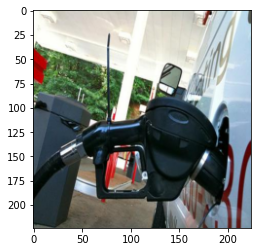

In [51]:
imshow(train_dataset[0][0])

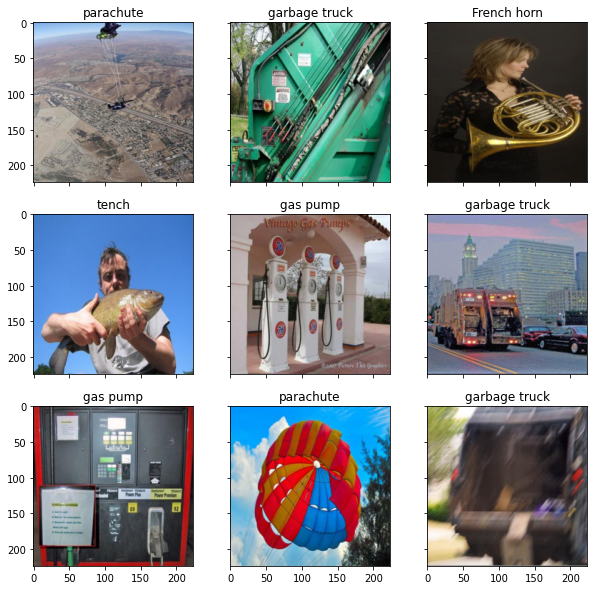

In [54]:
plot_train_set()

### Training Loop

In [17]:
def train(model, opt, loss_fn, epochs, train_data, val_data, name, path):
    
    losses = {'train': [], 'val': []}
    metrics = {'train': [], 'val': []}
    lr_scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.1)
    for epoch in range(epochs):
        print('Epoch {}/{}:'.format(epoch, epochs - 1))
        for phase in ['train', 'val']:
            running_acc = 0.
            running_loss = 0.
            # train phase
            if phase == 'train':
                dataloader = train_data
                model.train()
            # eval phase    
            else:
                dataloader = val_data
                model.eval()
            # iterate over batch    
            for X_batch, y_batch in tqdm(dataloader, desc=f'{phase} iter:'):
                opt.zero_grad()
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                with torch.set_grad_enabled(phase == 'train'):
                    y_pred = model(X_batch)
                    #print(y_pred.shape, y_batch.shape)
                    loss_value = loss_fn(y_pred, y_batch)
                    if phase == 'train':
                        loss_value.backward()
                        opt.step()
                    
                preds = y_pred.argmax(-1)
                corrects = (preds == y_batch).float()
                running_acc += corrects.mean()
                running_loss += loss_value.item()
            
            epoch_loss = running_loss / len(dataloader)
            epoch_acc = running_acc.cpu() / len(dataloader)
            
            if phase == 'train':
                lr_scheduler.step()
            
            losses[phase].append(epoch_loss)
            metrics[phase].append(epoch_acc) 
            # save model weights
            model_weights = model.state_dict()
            torch.save(model_weights, path)
        
            print('{} Loss: {:.4f}'.format(phase, epoch_loss))
            print('{} Accuracy: {:.4f}'.format(phase, epoch_acc))
            
    # save losses and metrics        
    with open(f'{name}_losses.pkl', 'wb') as loss_file:
        pickle.dump(losses, loss_file)
    
    with open(f'{name}_metrics.pkl', 'wb') as metrics_file:
        pickle.dump(metrics, metrics_file)
            
    return losses, metrics

### Inference

In [83]:
def predict_one_sample(model, inputs):
    """
    Returns the probability vector of the sample 
    """
    inputs = inputs.to(device)
    model.eval()
    with torch.no_grad():
        out = model(inputs)
        proba = torch.nn.functional.softmax(out, dim=1)
    return proba

def predict(model, test_loader):
    """Returns the probabilities vectors for each sample in test set"""
    with torch.no_grad():
        logits = []
    
        for inputs in test_loader:
            inputs = inputs.to(device)
            model.eval()
            outputs = model(inputs).cpu()
            logits.append(outputs)
            
    probs = nn.functional.softmax(torch.cat(logits), dim=1).numpy()
    return probs

def make_predictions(model, images):
    """Return class for each sample in the test set"""
    predictions = np.argmax(predict(model, images), axis=-1)
    return predictions

In [84]:
idxs = range(len(test_dataset)) 
imgs = [test_dataset[id][0].unsqueeze(0) for id in idxs]
actual_labels = [test_dataset[id][1] for id in idxs]

### Training AlexNet

In [72]:
alex = AlexNet().to(device)
alex

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [60]:
epochs = 10 # num of epochs 
opt = torch.optim.Adam(alex.parameters(), lr=1e-4) # optimizer 
loss_fn = nn.CrossEntropyLoss() # loss functions 
path = 'Alex.pth' # path where model weights are saved 
name = 'alex' # name where losses and metrics are saved 

In [83]:
losses, metrics = train(model, opt, loss_fn, epochs, train_loader, val_loader, name, path)

Epoch 0/9:


train iter:: 100%|██████████| 114/114 [00:25<00:00,  4.42it/s]


train Loss: 2.5720
train Accuracy: 0.1299


val iter:: 100%|██████████| 29/29 [00:05<00:00,  5.40it/s]


val Loss: 2.0683
val Accuracy: 0.2604
Epoch 1/9:


...

val Loss: 1.0060
val Accuracy: 0.6935
Epoch 9/9:


train iter:: 100%|██████████| 114/114 [00:25<00:00,  4.56it/s]


train Loss: 0.8021
train Accuracy: 0.7391


val iter:: 100%|██████████| 29/29 [00:05<00:00,  5.24it/s]


val Loss: 0.9949
val Accuracy: 0.6908


In [62]:
with open('alex_losses.pkl', 'rb') as f:
    alex_losses = pickle.load(f)

with open('alex_metrics.pkl', 'rb') as f:
    alex_metrics = pickle.load(f)

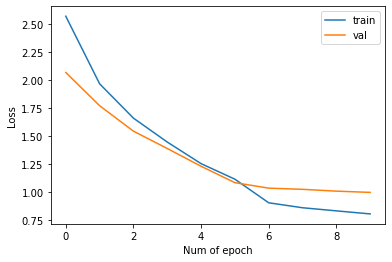

In [64]:
plt.plot(alex_losses['train'], label='train')
plt.plot(alex_losses['val'], label='val')
plt.xlabel('Num of epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

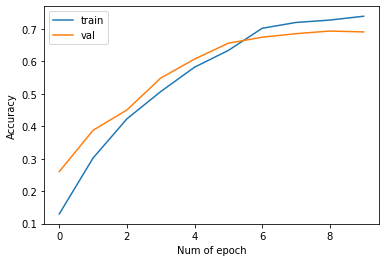

In [66]:
plt.plot(alex_metrics['train'], label='train')
plt.plot(alex_metrics['val'], label='val')
plt.xlabel('Num of epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### AlexNet on test dataset

In [75]:
alex = AlexNet().to(device)
path = 'Alex.pth'
alex.load_state_dict(torch.load(path))

In [80]:
# make predictions 
predictions_alex = make_predictions(alex, imgs)
acc_alex = accuracy_score(predictions_alex, actual_labels)

print(f'The accuracy on the test set of AlexNet is {round(acc_alex, 4)}')

The accuracy on the test set of AlexNet is 0.6779


### TRAINING VGG

In [19]:
vgg = VGG13().to(device)
vgg

VGG13(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1):

In [124]:
epochs = 10
#opt = torch.optim.SGD(vgg.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-4)
opt = torch.optim.Adam(vgg.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()
path = 'VGG.pth'
name = 'vgg'

In [125]:
losses_vgg, metrics_vgg = train(vgg, opt, loss_fn, epochs, train_loader, val_loader, name, path)

Epoch 0/9:


train iter:: 100%|██████████| 456/456 [01:12<00:00,  6.31it/s]


train Loss: 2.1423
train Accuracy: 0.2001


val iter:: 100%|██████████| 114/114 [00:09<00:00, 11.63it/s]


val Loss: 1.9118
val Accuracy: 0.3074
Epoch 1/9:


...

val Loss: 1.1784
val Accuracy: 0.6216
Epoch 9/9:


train iter:: 100%|██████████| 456/456 [01:12<00:00,  6.28it/s]


train Loss: 0.9535
train Accuracy: 0.6816


val iter:: 100%|██████████| 114/114 [00:09<00:00, 11.62it/s]


val Loss: 1.1745
val Accuracy: 0.6211


In [20]:
with open('vgg_losses.pkl', 'rb') as f:
    vgg_losses = pickle.load(f)

with open('vgg_metrics.pkl', 'rb') as f:
    vgg_metrics = pickle.load(f)

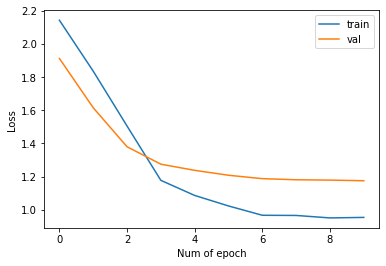

In [22]:
plt.plot(vgg_losses['train'], label='train')
plt.plot(vgg_losses['val'], label='val')
plt.xlabel('Num of epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

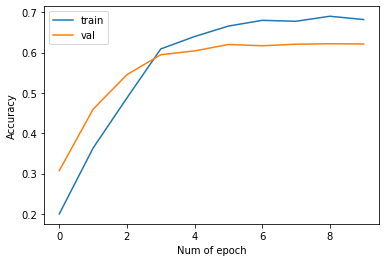

In [23]:
plt.plot(vgg_metrics['train'], label='train')
plt.plot(vgg_metrics['val'], label='val')
plt.xlabel('Num of epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### VGG on test set

In [64]:
vgg = VGG13().to(device)
path = 'VGG.pth'
vgg.load_state_dict(torch.load(path))

<All keys matched successfully>

In [65]:
predictions_vgg = make_predictions(vgg, imgs)
acc_vgg = accuracy_score(predictions_vgg, actual_labels)

print(f'The accuracy on the test set of VGG is {round(acc_vgg, 4)}')

The accuracy on the test set of VGG is 0.6136


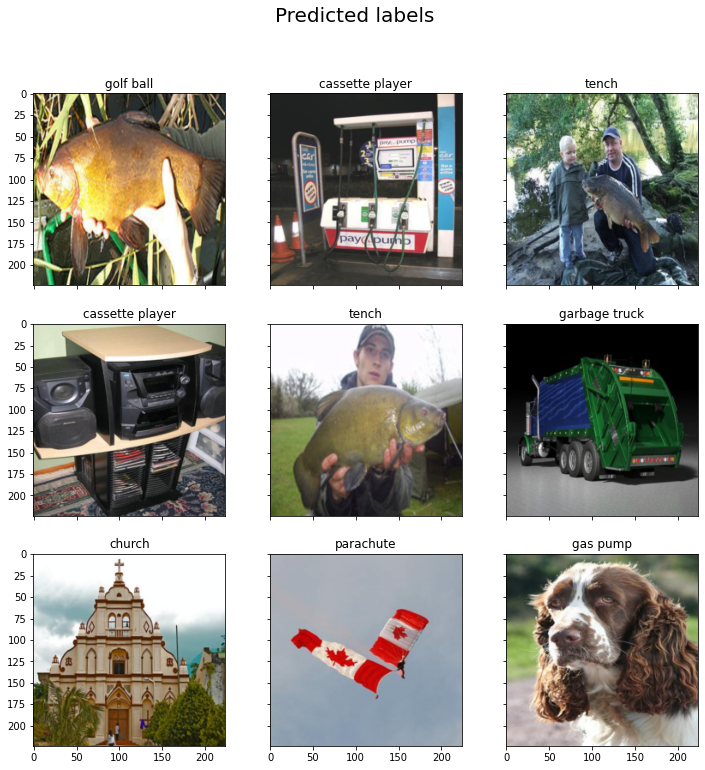

In [41]:
plot_results(vgg, test_dataset)

### Training ResNet 

In [48]:
resnet = ResNet18(ResBlock).to(device)

In [49]:
resnet

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (linear): Linear(in_features=256, out_features=10, bias=True)
  (layer1): Sequential(
    (0): ResBlock(
      (conv_block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Identity()
    )
    (1): ResBlock(
      (conv_block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d

In [ ]:
epochs = 10
opt = torch.optim.Adam(resnet.parameters(), lr=1e-4, weight_decay=1e-5)
loss_fn = nn.CrossEntropyLoss()
path = 'Resnet_with_reg.pth'
name = 'resnet_with_reg'

In [165]:
losses_res, metrics_res = train(resnet, opt, loss_fn, epochs, train_loader, val_loader, name, path)

Epoch 0/9:


train iter:: 100%|██████████| 228/228 [00:38<00:00,  5.94it/s]


train Loss: 1.6448
train Accuracy: 0.4370


val iter:: 100%|██████████| 57/57 [00:06<00:00,  9.02it/s]


val Loss: 1.5513
val Accuracy: 0.4928
Epoch 1/9:


...

val Loss: 0.7344
val Accuracy: 0.7699
Epoch 9/9:


train iter:: 100%|██████████| 228/228 [00:37<00:00,  6.00it/s]


train Loss: 0.1781
train Accuracy: 0.9790


val iter:: 100%|██████████| 57/57 [00:06<00:00,  9.06it/s]

val Loss: 0.7367
val Accuracy: 0.7688


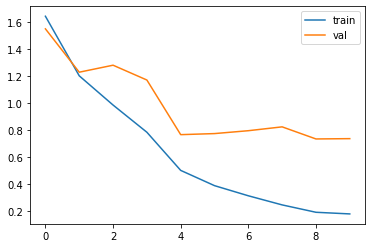

In [166]:
plt.plot(losses_res['train'], label='train')
plt.plot(losses_res['val'], label='val')
plt.legend()
plt.show()

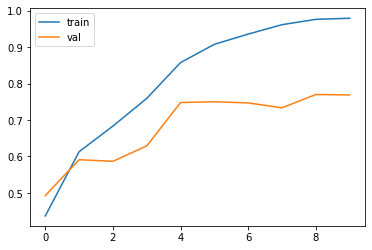

In [167]:
plt.plot(metrics_res['train'], label='train')
plt.plot(metrics_res['val'], label='val')
plt.legend()
plt.show()

### ResNet on test set

In [85]:
resnet = ResNet18(ResBlock).to(device)
path = 'ResNet_exp/Resnet.pth'
resnet.load_state_dict(torch.load(path))

<All keys matched successfully>

In [86]:
predictions_resnet = make_predictions(resnet, imgs)
acc_res = accuracy_score(predictions_resnet, actual_labels)

print(f'The accuracy on the test set of ResNet is {round(acc_res, 4)}')

The accuracy on the test set of ResNet is 0.7578


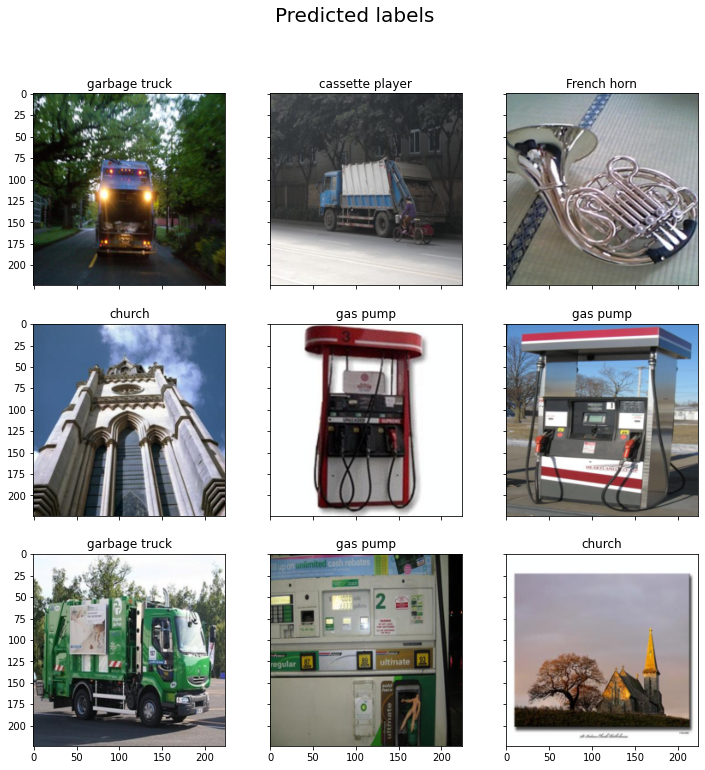

In [31]:
plot_results(resnet, test_dataset)

### Experiments with RESNET (to be continued...)

In [33]:
with open('ResNet_exp/resnet_losses.pkl', 'rb') as f:
    res_losses = pickle.load(f)

with open('ResNet_exp/resnet_metrics.pkl', 'rb') as f:
    res_metrics = pickle.load(f)

In [35]:
with open('ResNet_exp/resnet_with_reg_losses.pkl', 'rb') as f:
    res_with_reg_losses = pickle.load(f)

with open('ResNet_exp/resnet_with_reg_metrics.pkl', 'rb') as f:
    res_with_reg_metrics = pickle.load(f)

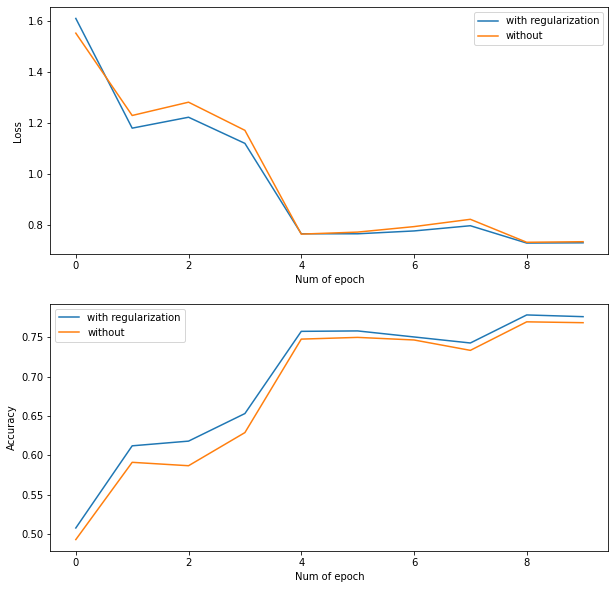

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

axes[0].plot(res_losses['val'], label='with regularization')
axes[0].plot(res_with_reg_losses['val'], label='without')
axes[0].legend()
axes[0].set_xlabel('Num of epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(res_metrics['val'], label='with regularization')
axes[1].plot(res_with_reg_metrics['val'], label='without')
axes[1].legend()
axes[1].set_xlabel('Num of epoch')
axes[1].set_ylabel('Accuracy')

plt.show()